<style>
:root { --navy:#172033; --blue:#2563eb; --cyan:#06b6d4; --paper:#f8fafc; --line:#dbeafe; }
.lab-hero { padding:32px 36px; border-radius:20px; color:white; background:linear-gradient(125deg,#172033 0%,#1d4ed8 60%,#06b6d4 100%); box-shadow:0 12px 28px rgba(37,99,235,.22); }
.lab-hero h1 { margin:0 0 8px; font-size:34px; letter-spacing:-.7px; }
.lab-hero p { margin:6px 0; opacity:.94; }
.lab-grid { display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:12px; margin:18px 0; }
.lab-card { padding:16px; border:1px solid var(--line); border-radius:14px; background:var(--paper); }
.lab-card b { color:var(--blue); }
.lab-note { border-left:5px solid var(--cyan); padding:12px 16px; background:#ecfeff; border-radius:8px; }
.lab-pending { border-left:5px solid #f59e0b; padding:12px 16px; background:#fffbeb; border-radius:8px; }
table { font-size:13px !important; }
</style>

<div class="lab-hero">
  <h1>Laboratorio 7 · Spark MLlib</h1>
  <p><b>Actividades 1–7: exploración, segmentación, modelado y evaluación en 2026</b> · ENEIC Personas 2025–2026</p>
  <p>Universidad del Valle de Guatemala · CC3084 Data Science · Sección 10 · Grupo 1 · Segundo semestre 2026</p>
</div>

<div class="lab-grid">
  <div class="lab-card"><b>Jorge Gabriel Palacios Sales</b><br>231385</div>
  <div class="lab-card"><b>Pablo Daniel Barillas Moreno</b><br>22193</div>
  <div class="lab-card"><b>Roberto Emiliano Otoniel</b><br>23968</div>
</div>

## 0. Objetivo, preguntas y alcance

Este notebook identifica perfiles de trabajadores asalariados y evalúa qué tan bien puede estimarse su salario mensual mediante Spark 3.5.1 y `pyspark.ml`. El procedimiento conserva la trazabilidad por archivo, evita interpretar asociaciones como causalidad y calcula las métricas sobre los conjuntos completos.

**Alcance ejecutado:** actividades 1–7. El análisis exhaustivo de errores (actividad 8) se construye sobre las predicciones de 2026 que deja guardadas la sección 7.

**Diseño temporal:** 2025T1–2025T3 se utilizan para entrenamiento; 2025T4 para validación y selección. Después, cada configuración ganadora se reentrena con los cuatro trimestres de 2025 y se evalúa una sola vez en 2026T1. 2026T1 nunca se consulta para escoger configuraciones.

In [6]:
from pathlib import Path
import platform
import sys

from IPython.display import HTML, Image, display
import pandas as pd
import pyspark
from pyspark.sql import SparkSession, functions as F

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "src").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from lab7.config import (
    FIGURES_DIR, FINAL_FOREST_MODEL, FINAL_LINEAR_MODEL, FINAL_TRAIN_PERIODS,
    MODEL_DIR, TABLES_DIR, TEST_PERIODS, TRAIN_PERIODS, VALIDATION_PERIODS,
    ensure_directories,
)
from lab7.data import (
    convert_excel_sources, counts_by_file, duplicate_key_audit,
    filter_analytical_population, harmonize, load_periods,
    missingness_before_filters, observed_source_quarters, save_prepared_sets,
)
from lab7.analysis import (
    categorical_distribution, descriptive_statistics, kmeans_search,
    median_salary_by, pearson_correlation, quarterly_summary, salary_plot_sample,
)
from lab7.modeling import (
    baseline_metrics, comparison_table, final_comparison_table, final_stage_plan,
    fit_final_models, fit_linear_candidates, fit_random_forest_candidates,
)
from lab7.visualization import (
    plot_categorical_distributions, plot_correlation_heatmap,
    plot_group_medians, plot_kmeans_selection, plot_model_comparison,
    plot_quarterly_summary, plot_salary_distribution,
)

ensure_directories()
spark = (
    SparkSession.builder
    .appName("Lab7-ENEIC-SparkMLlib")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

versions = pd.DataFrame({
    "componente": ["Python", "PySpark", "Java", "Semilla"],
    "valor": [platform.python_version(), pyspark.__version__, spark.sparkContext._jvm.java.lang.System.getProperty("java.version"), "42"],
})
display(versions)
assert pyspark.__version__.startswith("3.5"), "La guía requiere Spark 3.5.x"

,componente,valor
0,Python,3.11.8
1,PySpark,4.2.0
2,Java,24.0.2
3,Semilla,42


AssertionError: La guía requiere Spark 3.5.x

## 1. Carga, armonización y calidad

Cada Excel se procesa por separado y únicamente con las 14 columnas requeridas. Primero se crea un DataFrame de Spark con esquema explícito de texto —para evitar inferencias distintas entre trimestres— y luego se guarda en Parquet. Las conversiones numéricas y categóricas se realizan posteriormente en Spark.

In [ ]:
conversion_audit = convert_excel_sources(spark, force=False)
display(conversion_audit)
assert (conversion_audit["registros"] == conversion_audit["esperados"]).all()

raw_2025 = load_periods(spark, ["2025T1", "2025T2", "2025T3", "2025T4"]).cache()
raw_2026 = load_periods(spark, ["2026T1"]).cache()
harmonized_2025 = harmonize(raw_2025).cache()
harmonized_2026 = harmonize(raw_2026).cache()

selected_view = [
    "periodo_archivo", "archivo_origen", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA",
    "edad", "ocupado", "categoria_ocupacional", "salario_mensual", "antiguedad",
    "horas_semanales", "nivel_educativo", "dominio", "factor",
]
harmonized_2025.select(*selected_view).printSchema()
harmonized_2025.select(*selected_view).show(5, truncate=False)

FileNotFoundError: No se encontro la fuente requerida: \opt\app\working_dir\eneic\raw\Personas_ENEIC_I_2025.xlsx

In [ ]:
missingness_2025 = missingness_before_filters(raw_2025)
prepared_2025, filter_audit_2025 = filter_analytical_population(harmonized_2025)
prepared_2026, filter_audit_2026 = filter_analytical_population(harmonized_2026)
prepared_2025 = prepared_2025.cache()
prepared_2026 = prepared_2026.cache()

file_counts = counts_by_file(harmonized_2025, prepared_2025)
source_quarters = observed_source_quarters(raw_2025)
key_audit = duplicate_key_audit(harmonized_2025)

for name, table in {
    "conversion_fuentes.csv": conversion_audit,
    "faltantes_antes_filtros_2025.csv": missingness_2025,
    "auditoria_filtros_2025.csv": filter_audit_2025,
    "auditoria_filtros_2026.csv": filter_audit_2026,
    "conteos_por_archivo.csv": file_counts,
    "trimestre_fuente_observado.csv": source_quarters,
    "auditoria_claves.csv": key_audit,
}.items():
    table.to_csv(TABLES_DIR / name, index=False)

display(HTML("<h4>Faltantes antes de filtrar (2025)</h4>"))
display(missingness_2025.style.format({"porcentaje": "{:.2f}%"}))
display(HTML("<h4>Embudo de filtros 2025</h4>"))
display(filter_audit_2025)
display(HTML("<h4>Conteos por archivo</h4>"))
display(file_counts.style.format({"retencion_pct": "{:.2f}%"}))
display(HTML("<h4>TRIMESTRE original conservado</h4>"))
display(source_quarters)
display(HTML("<h4>Unicidad de periodo + hogar + persona</h4>"))
display(key_audit)

save_prepared_sets(prepared_2025, prepared_2026)

,variable,faltantes,porcentaje
8,P05D01,150651,73.97%
6,OCUPADOS,115454,56.69%
9,P05C07A,115454,56.69%
10,P05C07B,115454,56.69%
7,P05C16,115454,56.69%
11,P05H01A,115454,56.69%
12,P03A03A,26344,12.93%
3,ANIO,0,0.00%
13,DOMINIO,0,0.00%
2,FACTOR,0,0.00%


,paso,criterio,antes,excluidos,despues
0,0,Registros de entrada,203676,0,203676
1,1,Edad finita y >= 15,203676,62886,140790
2,2,Persona ocupada (OCUPADOS = 1),140790,52568,88222
3,3,"Categoria asalariada (P05C16 en 1,2,3,4)",88222,35197,53025
4,4,Salario finito y positivo,53025,0,53025
5,5,Componentes de antiguedad validos,53025,0,53025
6,6,Antiguedad <= edad,53025,0,53025
7,7,"Horas semanales en (0, 168]",53025,0,53025


,periodo_archivo,antes,despues,excluidos,retencion_pct
0,2025T1,51588,13419,38169,26.01%
1,2025T2,51167,13492,37675,26.37%
2,2025T3,51583,13450,38133,26.07%
3,2025T4,49338,12664,36674,25.67%


,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338


,grupos_duplicados,filas_involucradas,grupos_repeticion_exacta,grupos_en_conflicto
0,0,0,0,0


26/09/27 19:49:22 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


### Interpretación de calidad

- **2025-IV no se apila por posición:** contiene 302 columnas frente a 270 en los otros archivos. `unionByName` evita asociar variables distintas por su posición física.
- **Ausente por diseño vs. no respuesta:** una pregunta puede no corresponder por el flujo del cuestionario; una no respuesta sí era aplicable, pero quedó sin registrar. Ambos casos pueden verse vacíos, aunque tienen significados estadísticos diferentes.
- **Longitudinalidad:** la misma persona en dos períodos es una observación válida distinta; solo se audita la unicidad dentro de `periodo_archivo`.
- **Alcance:** la base filtrada no representa por sí sola a todos los trabajadores de Guatemala. Este análisis no ponderado describe registros elegibles. `FACTOR` se conserva para una futura estimación poblacional con el diseño muestral apropiado.
- Los códigos categóricos desconocidos se representan como `DESCONOCIDO`; el código educativo 0 se conserva como `Ninguno`.

## 2. Estadística descriptiva y exploración

,variable,n,media,mediana,desviacion_estandar,minimo,p25,p75,p95,maximo
0,salario_mensual,53025,"3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00"
1,edad,53025,35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00
2,antiguedad,53025,5.56,2.00,7.83,0.00,0.50,7.00,21.33,70.00
3,horas_semanales,53025,46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00


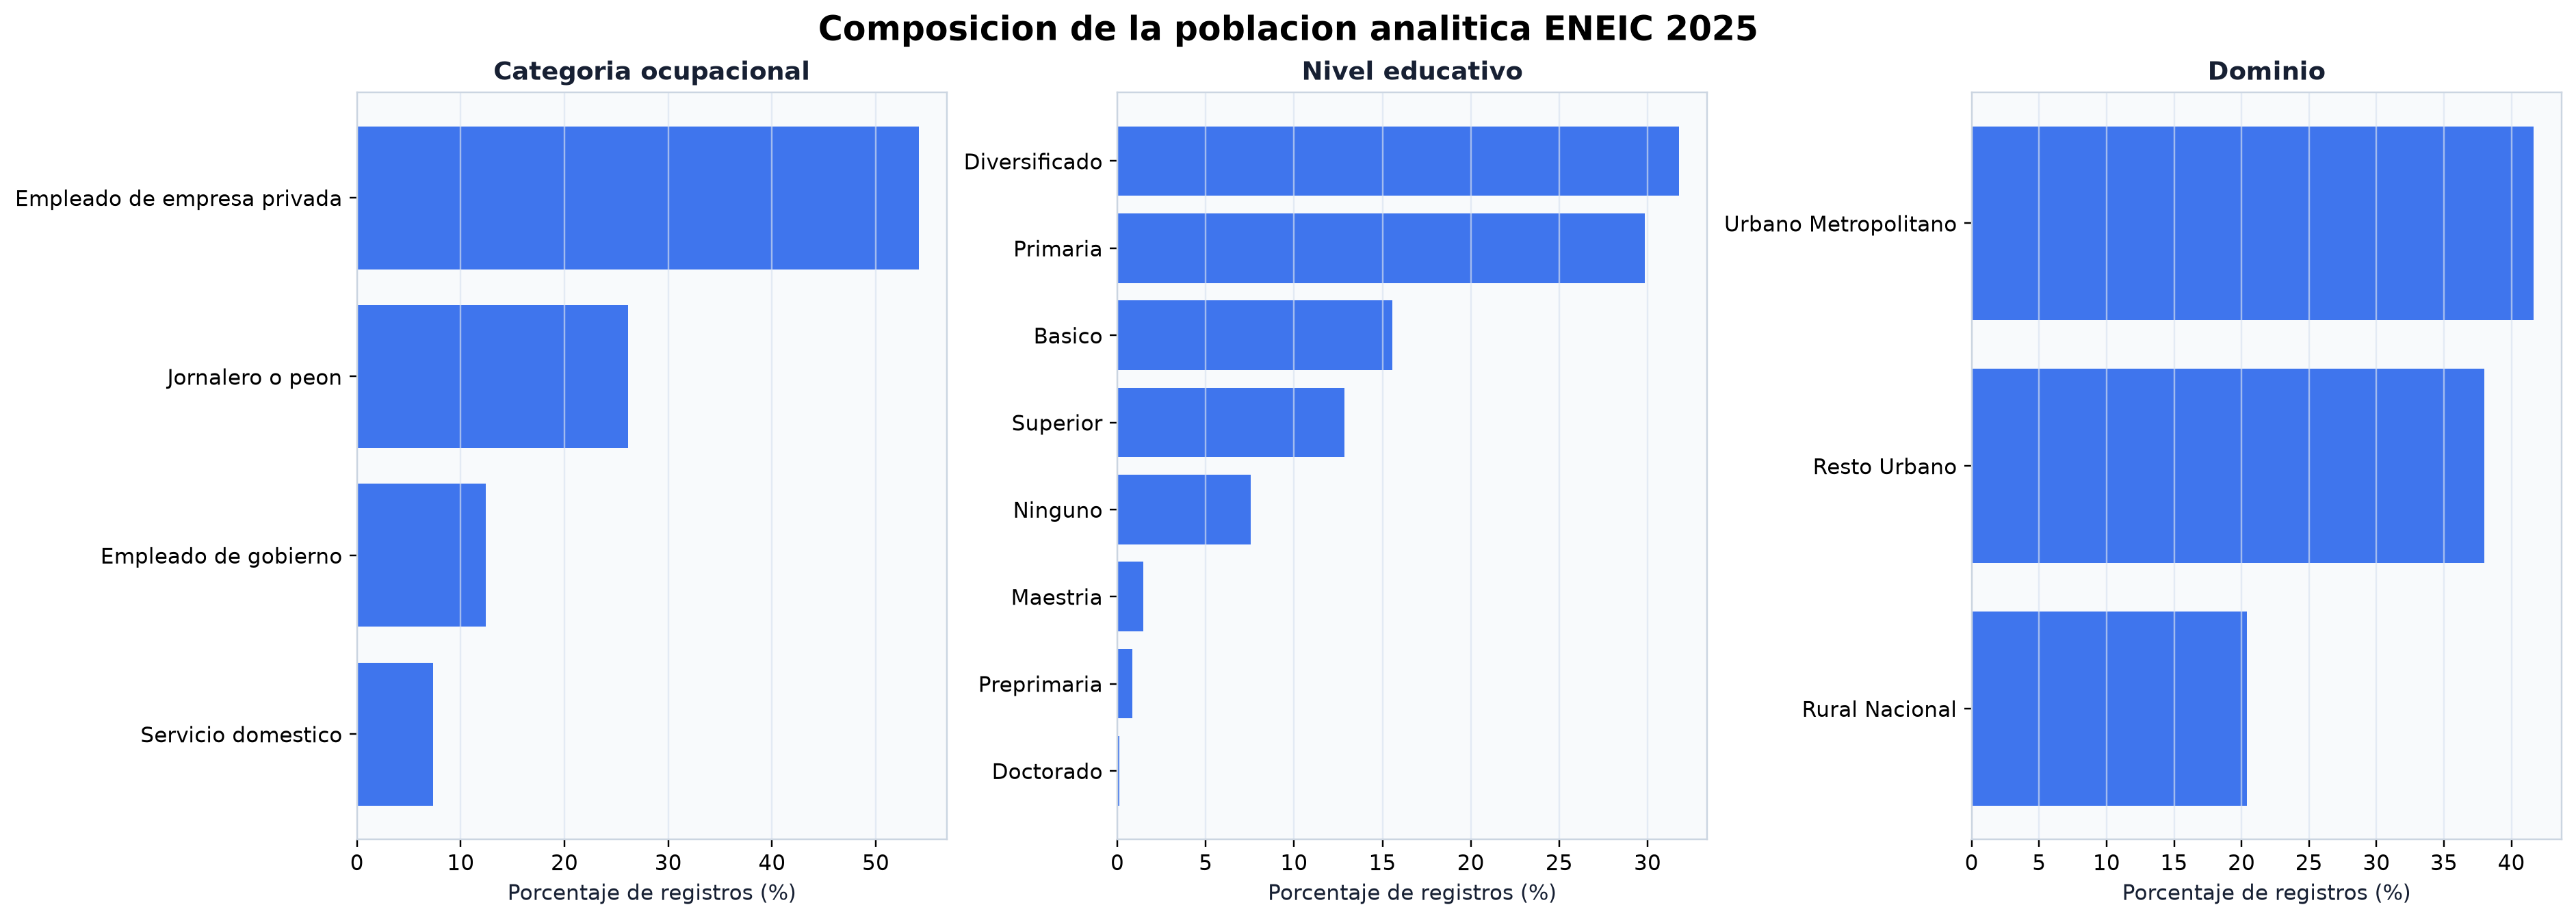

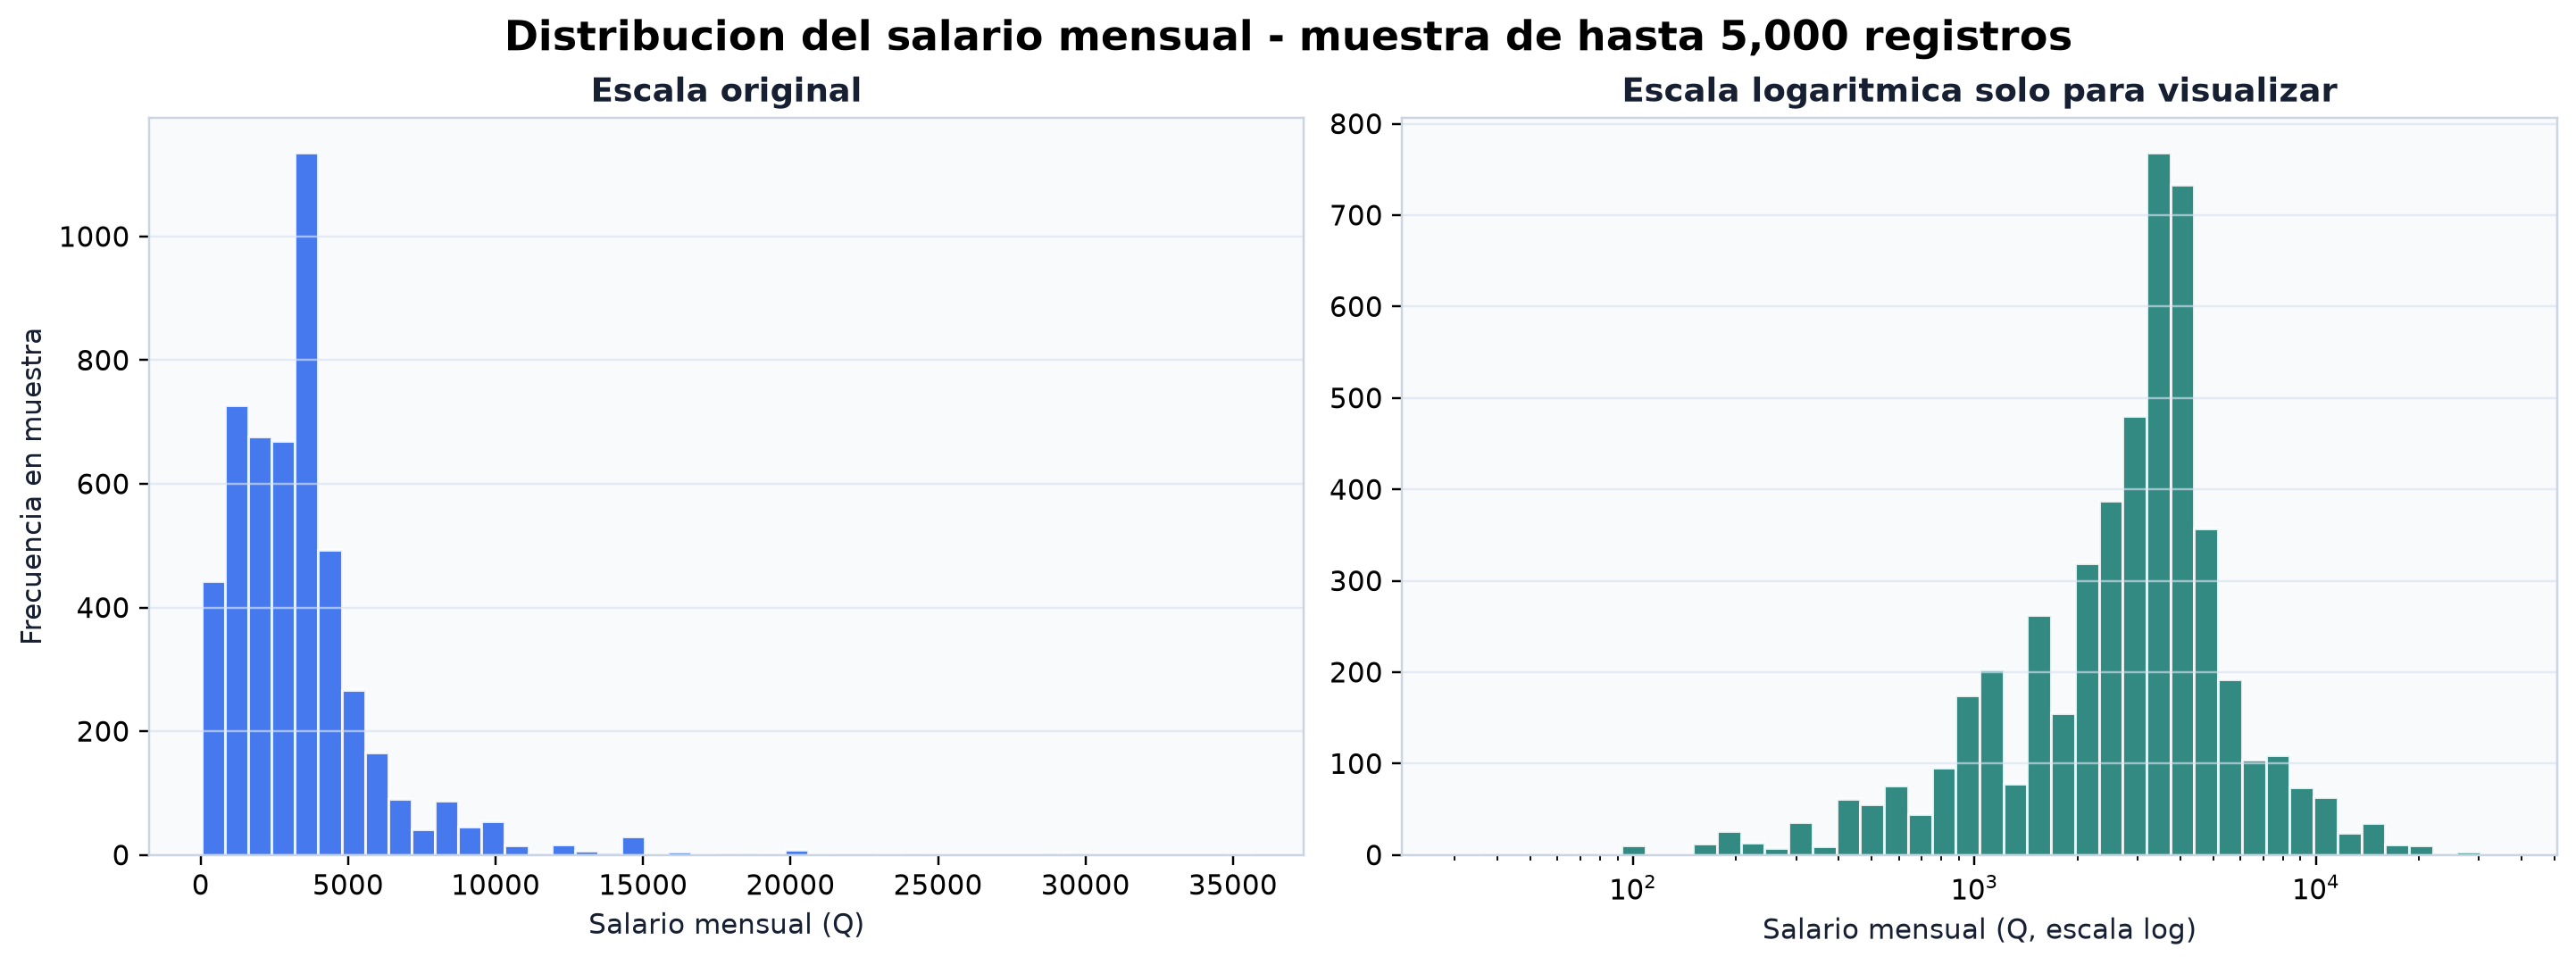

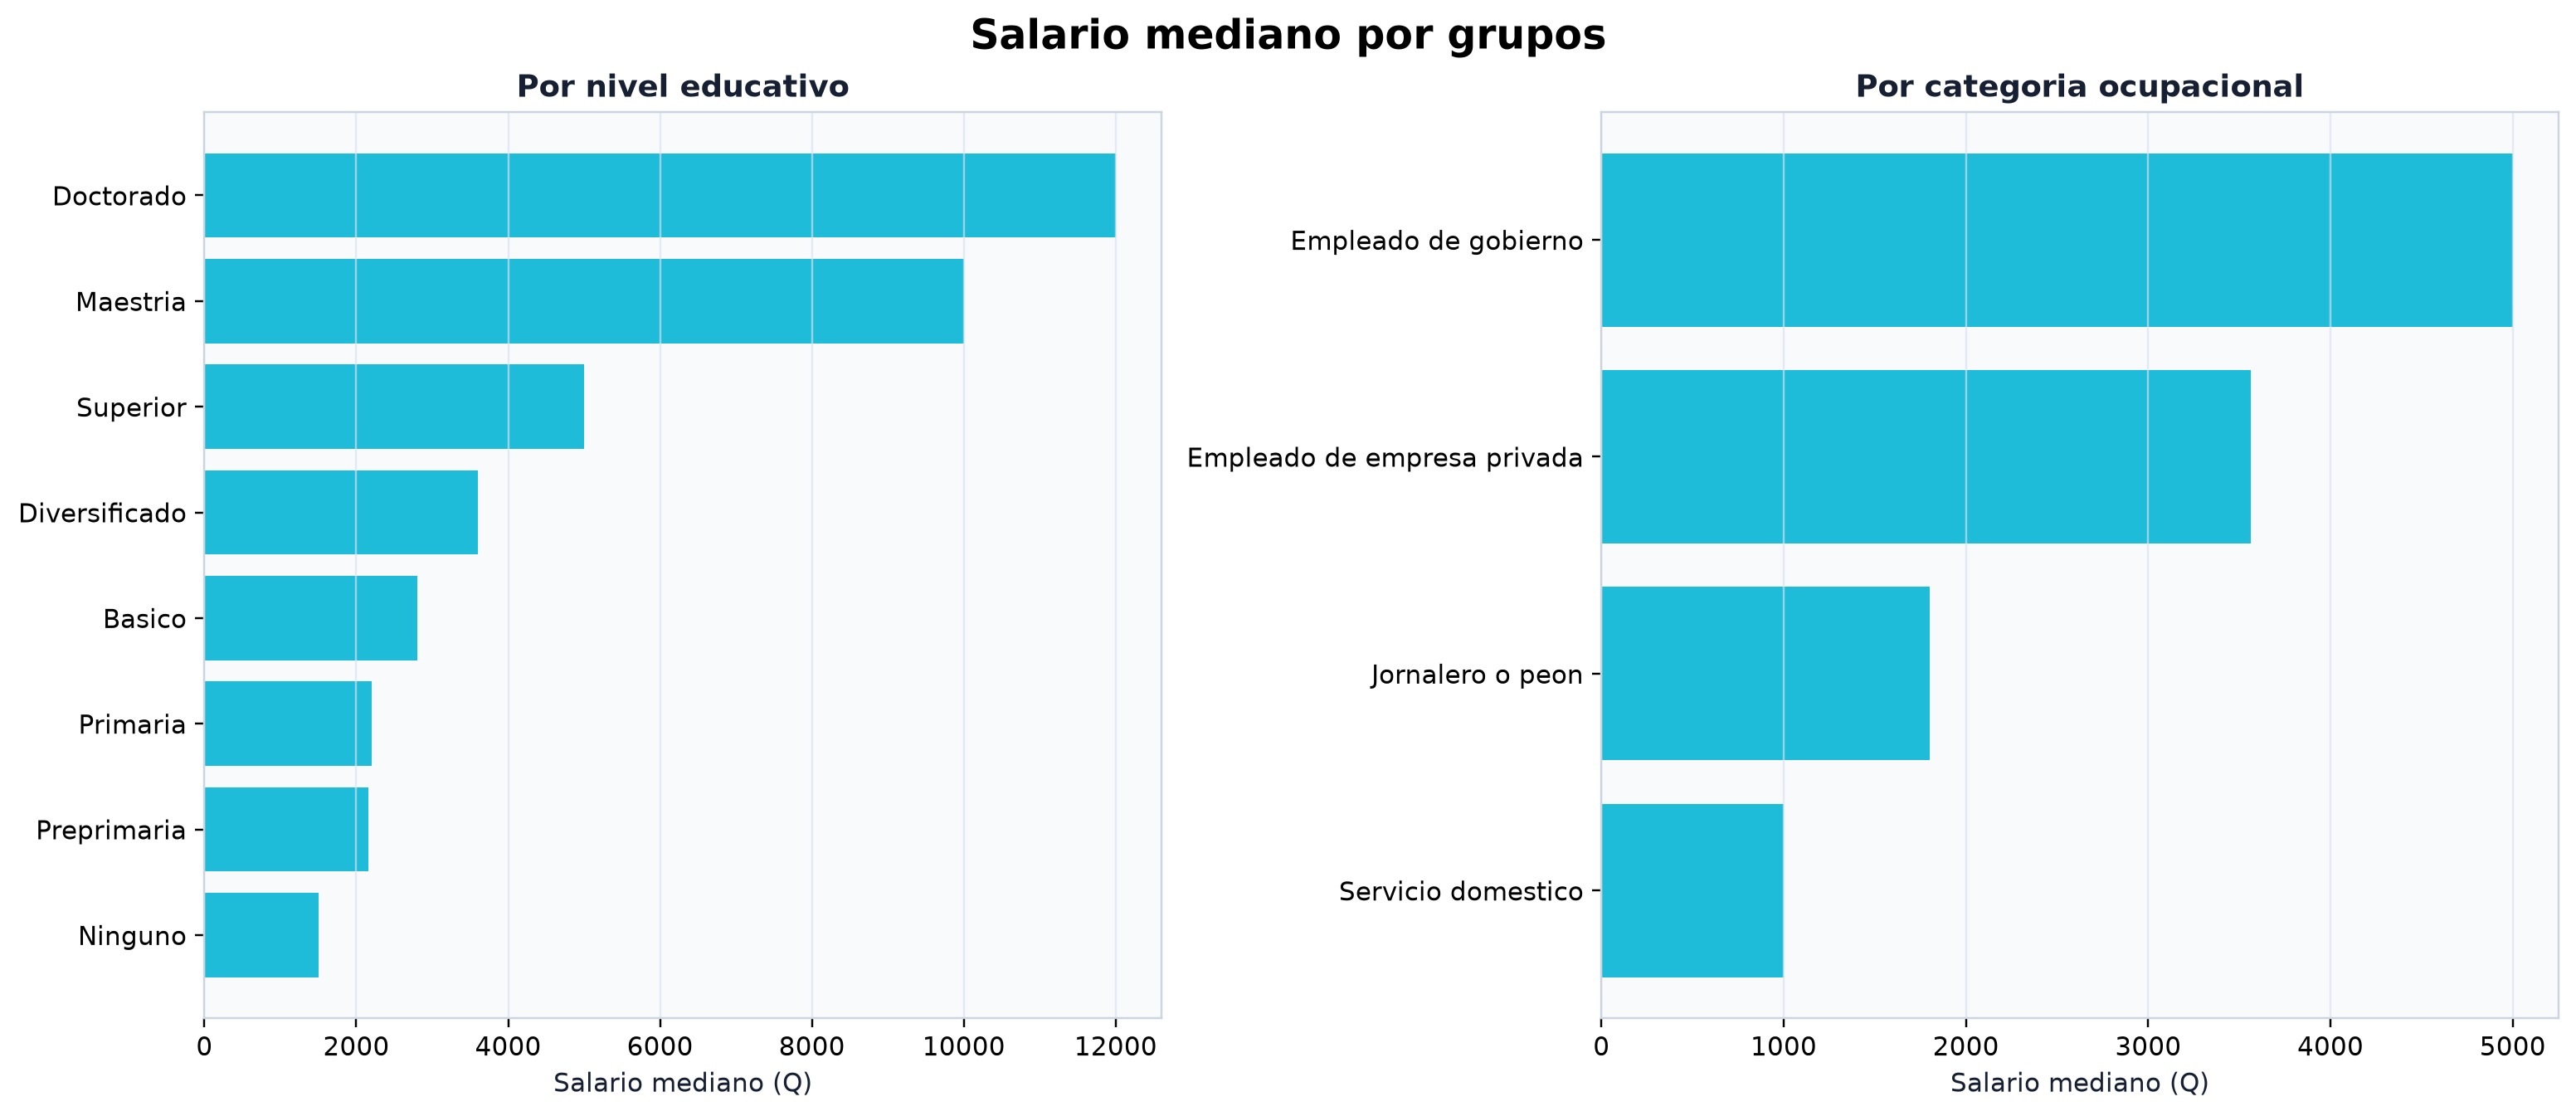

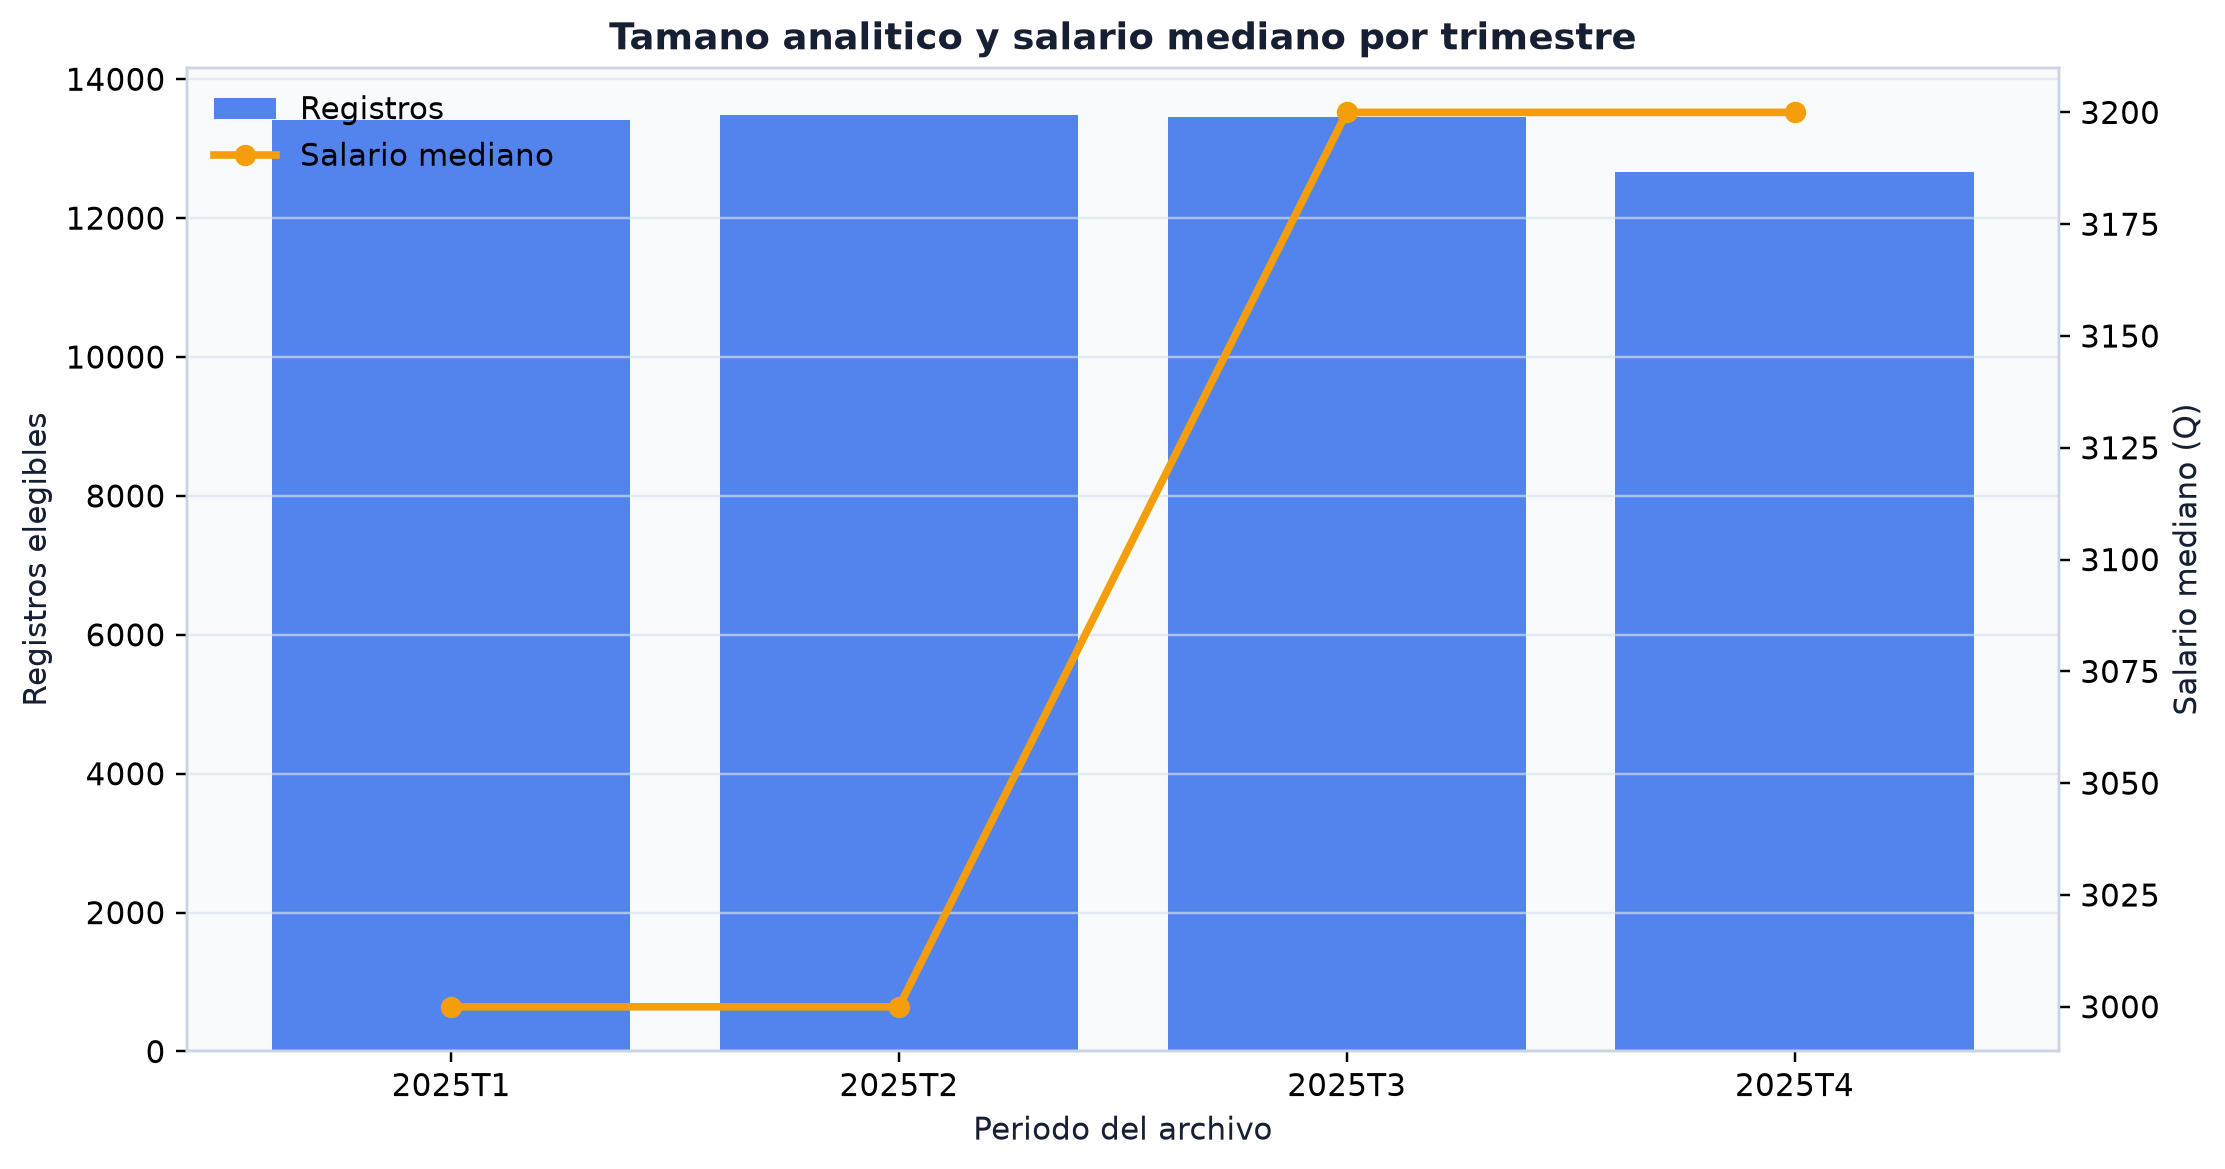

In [ ]:
descriptive = descriptive_statistics(prepared_2025)
distributions = pd.concat([
    categorical_distribution(prepared_2025, "categoria_ocupacional"),
    categorical_distribution(prepared_2025, "nivel_educativo"),
    categorical_distribution(prepared_2025, "dominio"),
], ignore_index=True)
salary_groups = pd.concat([
    median_salary_by(prepared_2025, "nivel_educativo"),
    median_salary_by(prepared_2025, "categoria_ocupacional"),
], ignore_index=True)
quarters = quarterly_summary(prepared_2025)
salary_sample = salary_plot_sample(prepared_2025, 5_000)

descriptive.to_csv(TABLES_DIR / "estadistica_descriptiva_2025.csv", index=False)
distributions.to_csv(TABLES_DIR / "distribuciones_categoricas.csv", index=False)
salary_groups.to_csv(TABLES_DIR / "salario_por_grupo.csv", index=False)
quarters.to_csv(TABLES_DIR / "resumen_trimestral.csv", index=False)

plot_categorical_distributions(distributions)
plot_salary_distribution(salary_sample)
plot_group_medians(salary_groups)
plot_quarterly_summary(quarters)

display(descriptive.style.format({c: "{:,.2f}" for c in descriptive.columns if c not in ["variable", "n"]}))
display(Image(filename=str(FIGURES_DIR / "distribuciones_categoricas.png")))
display(Image(filename=str(FIGURES_DIR / "distribucion_salario.png")))
display(Image(filename=str(FIGURES_DIR / "salario_mediano_grupos.png")))
display(Image(filename=str(FIGURES_DIR / "evolucion_trimestral.png")))

salary_row = descriptive.loc[descriptive["variable"] == "salario_mensual"].iloc[0]
shape = "asimetría positiva" if salary_row["media"] > salary_row["mediana"] else "asimetría negativa o débil"
display(HTML(f'''
<div class='lab-note'><b>Lectura descriptiva.</b> El salario presenta {shape}: la media es Q{salary_row['media']:,.2f} y la mediana Q{salary_row['mediana']:,.2f}. La diferencia y el máximo elevado justifican conservar los extremos para modelar, pero interpretar RMSE junto con MAE.</div>
'''))

## 3. Relaciones entre variables numéricas

26/09/27 19:49:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/27 19:49:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS

[Stage 183:==============>                                         (8 + 8) / 32]



,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


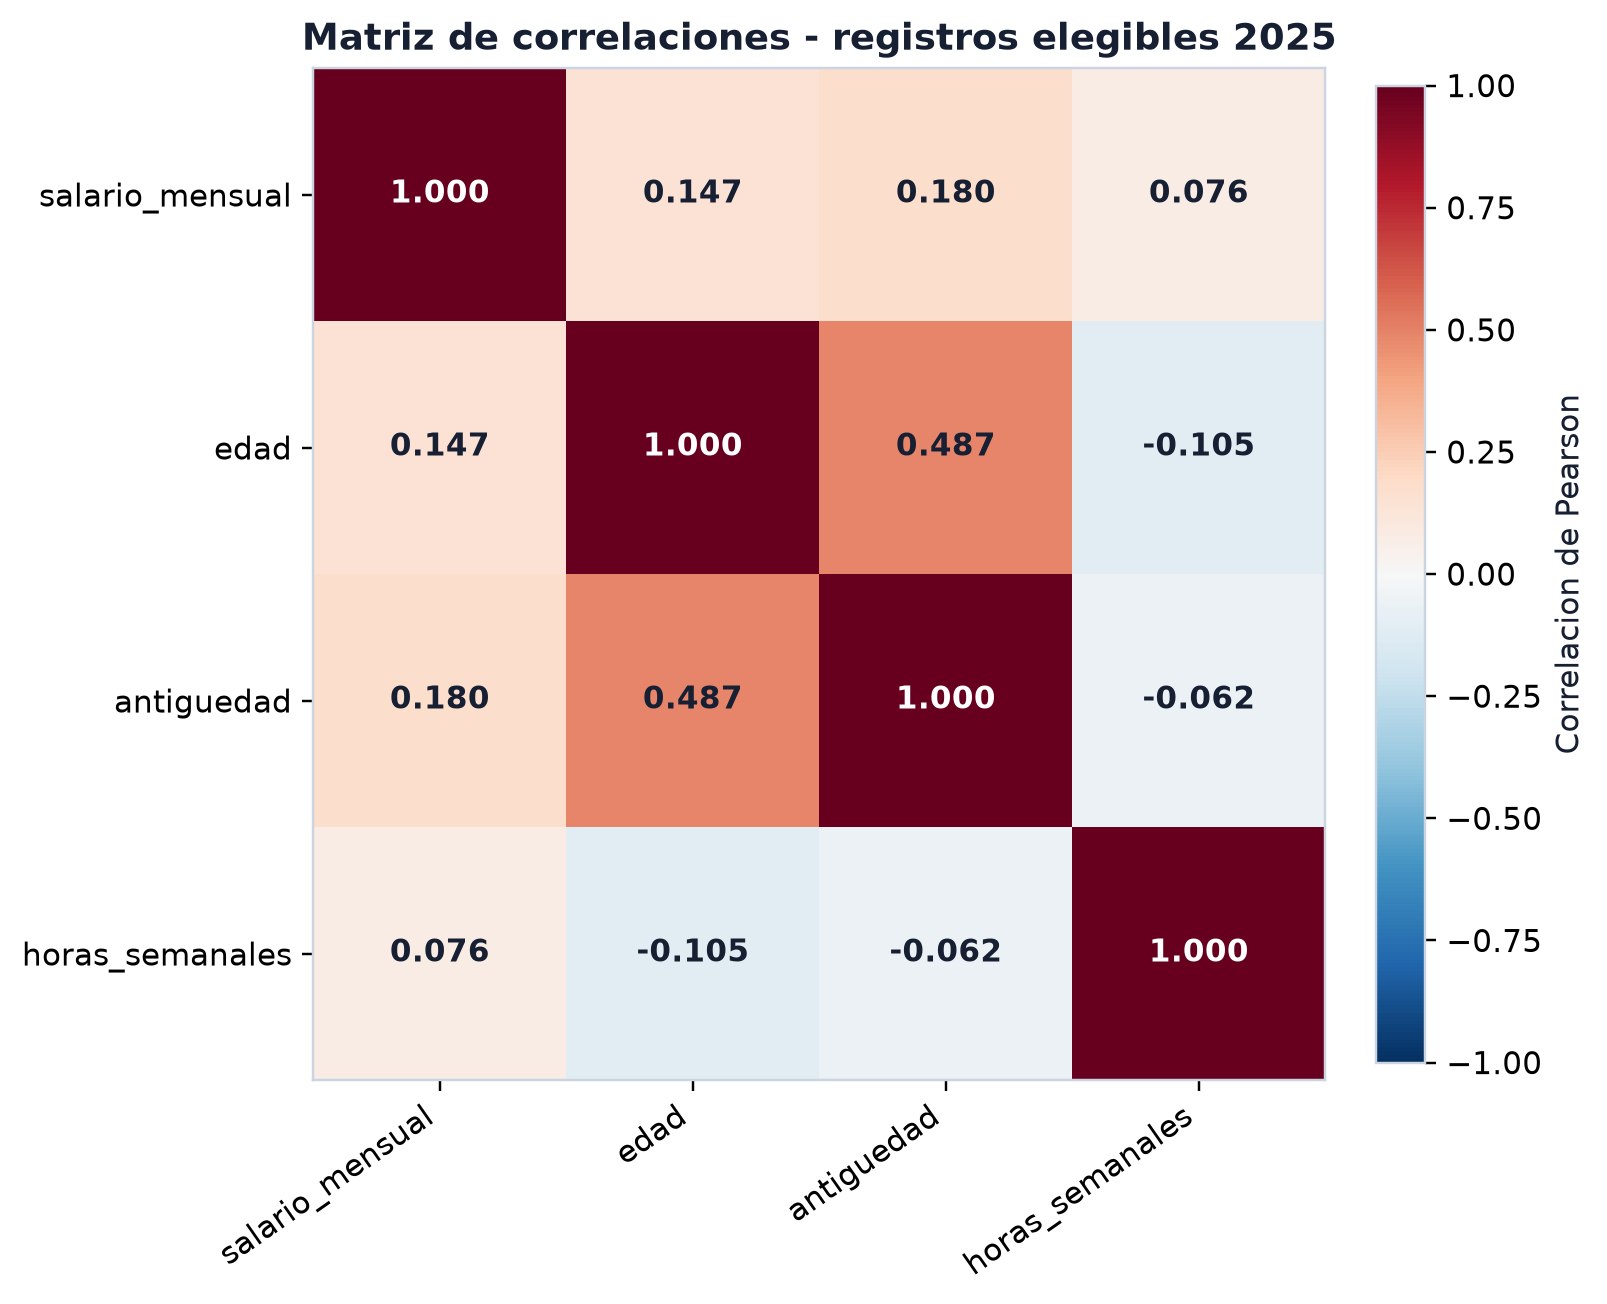

In [ ]:
correlation = pearson_correlation(prepared_2025)
correlation.to_csv(TABLES_DIR / "correlaciones_pearson.csv")
plot_correlation_heatmap(correlation)
display(correlation.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))
display(Image(filename=str(FIGURES_DIR / "correlaciones_pearson.png")))

salary_associations = correlation["salario_mensual"].drop("salario_mensual").abs().sort_values(ascending=False)
strongest = salary_associations.index[0]
age_tenure = correlation.loc["edad", "antiguedad"]
display(HTML(f'''
<div class='lab-note'><b>Interpretación.</b> Entre los predictores numéricos, <code>{strongest}</code> tiene la mayor asociación lineal absoluta con el salario (|r|={salary_associations.iloc[0]:.3f}). La relación edad-antigüedad es r={age_tenure:.3f}; es esperable que exista asociación, pero no equivalencia, porque personas de la misma edad pueden tener trayectorias laborales distintas.</div>
'''))

## 4. Segmentación de perfiles con KMeans

Se comparan K=2,3,4,5 en dos escenarios estandarizados: un perfil laboral sin salario y un perfil económico que sí lo incorpora. Esta comparación permite decidir con evidencia si el salario aporta separación o domina artificialmente los perfiles.

,escenario,k,silhouette
0,Perfil laboral (sin salario),2,0.5545
1,Perfil economico (con salario),2,0.5148
2,Perfil laboral (sin salario),5,0.4839
3,Perfil laboral (sin salario),4,0.4760
4,Perfil laboral (sin salario),3,0.4718
5,Perfil economico (con salario),5,0.3732
6,Perfil economico (con salario),4,0.3703
7,Perfil economico (con salario),3,0.3371


,cluster,n,edad_media,edad_mediana,antiguedad_media,antiguedad_mediana,horas_semanales_media,horas_semanales_mediana,porcentaje,descripcion
0,0,38421,29.07,28.00,2.42,1.33,48.21,46.00,72.46,"Edad bajo, antiguedad bajo, horas semanales alto"
1,1,14604,51.28,51.00,13.81,13.00,41.30,40.00,27.54,"Edad alto, antiguedad alto, horas semanales bajo"


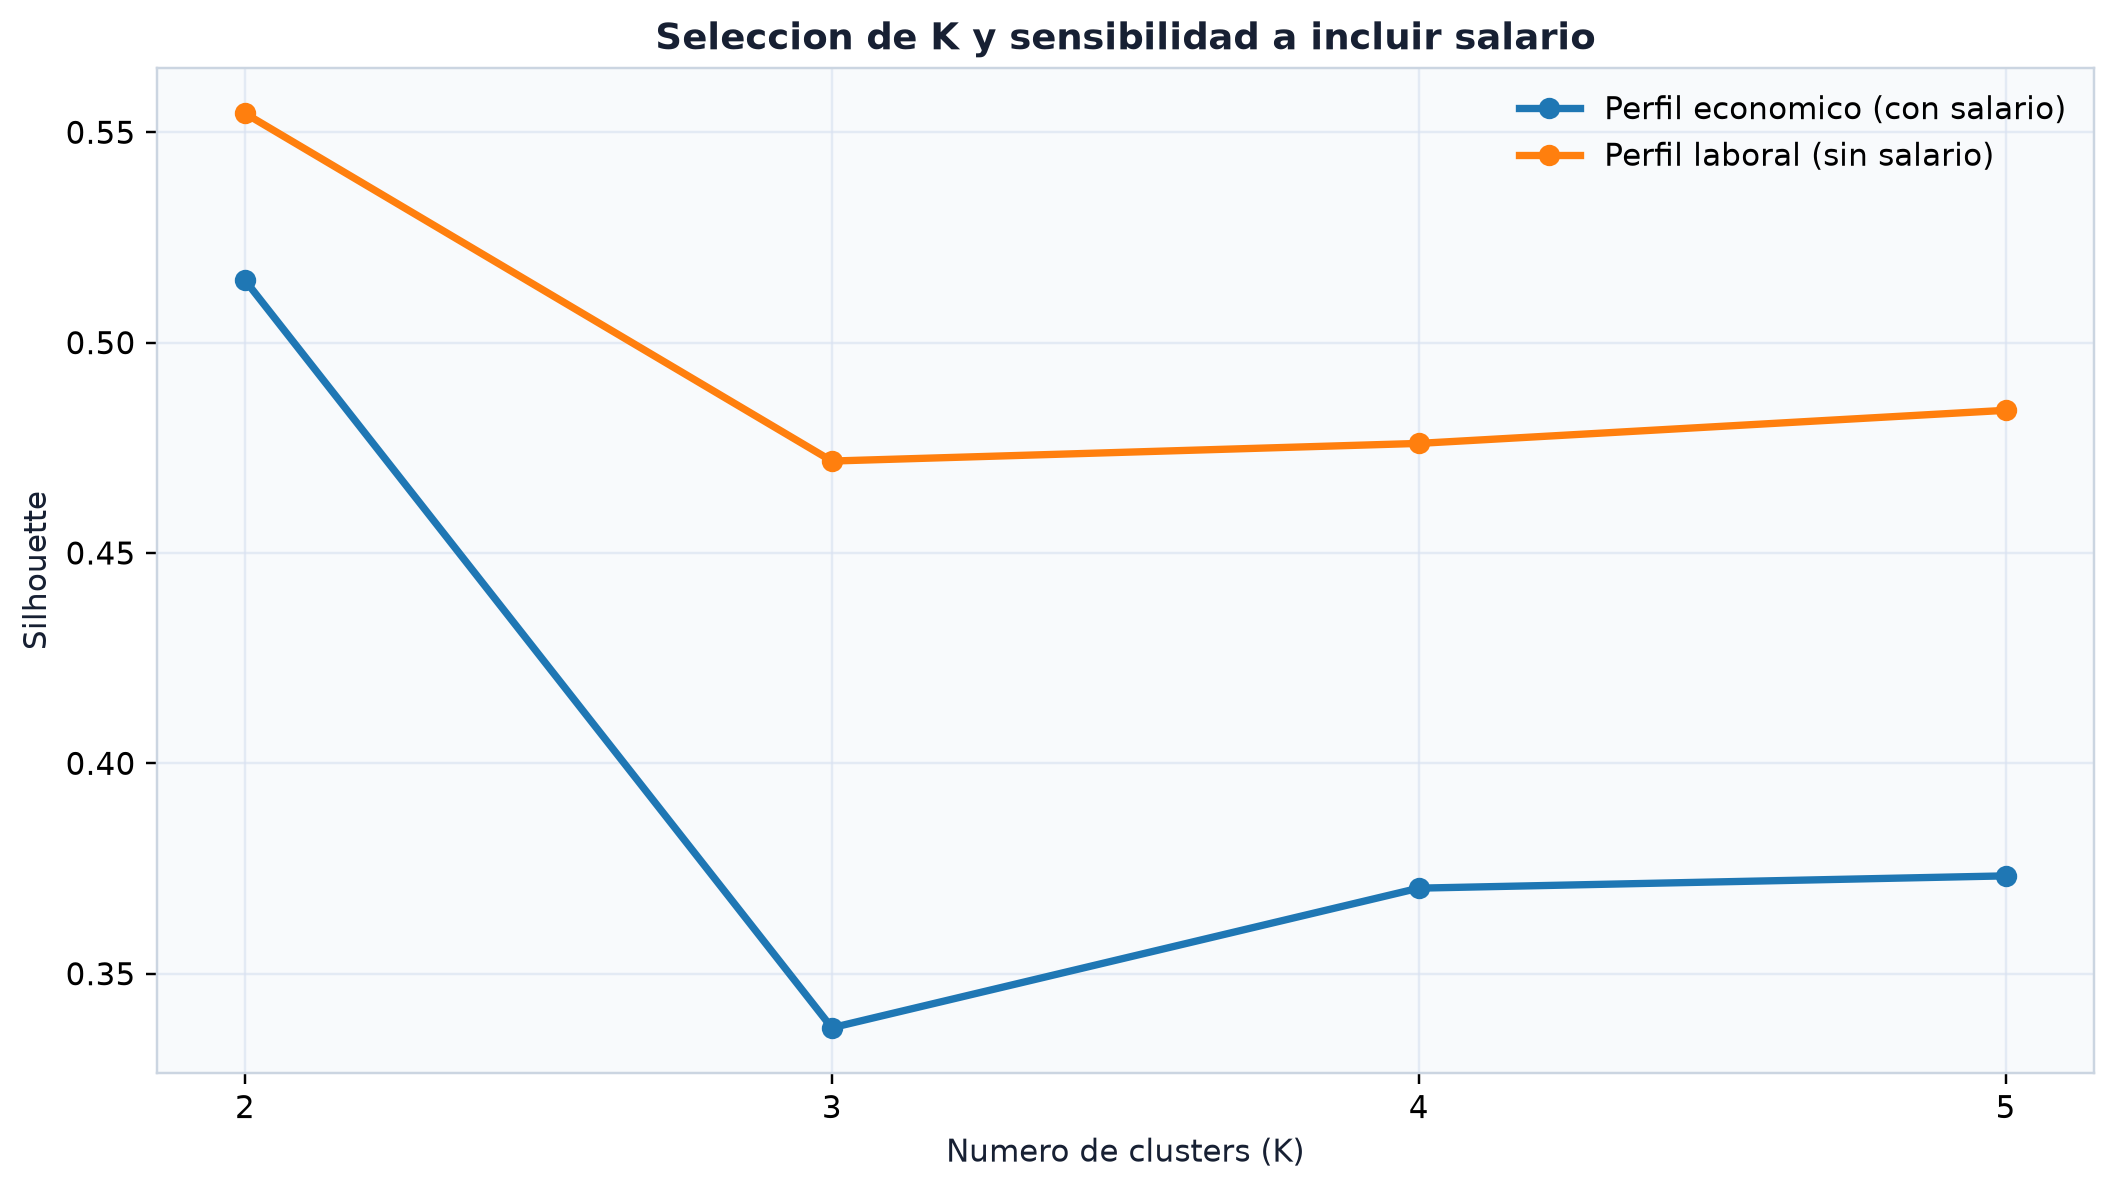

In [ ]:
kmeans_results, cluster_profiles, kmeans_model, best_scenario, best_k = kmeans_search(prepared_2025)
kmeans_results.to_csv(TABLES_DIR / "seleccion_kmeans.csv", index=False)
cluster_profiles.to_csv(TABLES_DIR / "perfiles_clusters.csv", index=False)
plot_kmeans_selection(kmeans_results)

display(kmeans_results.style.format({"silhouette": "{:.4f}"}))
display(cluster_profiles.style.format({c: "{:,.2f}" for c in cluster_profiles.columns if c not in ["cluster", "n", "descripcion"]}))
display(Image(filename=str(FIGURES_DIR / "seleccion_kmeans.png")))
display(HTML(f'''
<div class='lab-note'><b>Selección:</b> el mejor resultado fue <i>{best_scenario}</i> con K={best_k}. La selección maximiza silhouette y la tabla de perfiles asigna descripciones relativas a las medias globales; son segmentos descriptivos, no clases naturales ni juicios sobre las personas.</div>
'''))

## 5–6. Modelado supervisado y validación temporal

Se usan exactamente seis predictores: edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio. Todos los transformadores se ajustan únicamente con 2025T1–T3. La validación se realiza en 2025T4 y se compara contra la media salarial del entrenamiento.

,conjunto,registros
0,Entrenamiento 2025T1-T3,40361
1,Validacion 2025T4,12664
2,Test reservado 2026T1,13258


26/09/27 19:49:49 WARN Instrumentation: [42194df1] regParam is zero, which might cause numerical instability and overfitting.


26/09/27 19:49:50 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/09/27 19:49:50 WARN Instrumentation: [42194df1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/27 19:49:58 WARN DAGScheduler: Broadcasting large task binary with size 1144.0 KiB


,nombre,regParam,elasticNetParam,MAE,RMSE,R2
0,LR_sin_regularizacion,0.000000,0.000000,"1,210.14","2,186.42",0.4257
1,LR_ridge_0_1,0.100000,0.000000,"1,210.13","2,186.42",0.4257
2,LR_elastic_0_1,0.100000,0.500000,"1,210.11","2,186.42",0.4257


,nombre,numTrees,maxDepth,MAE,RMSE,R2
0,RF_50_arboles_d7,50,7,"1,109.94","2,074.15",0.4831
1,RF_25_arboles_d5,25,5,"1,165.67","2,165.11",0.4368


,modelo,MAE,RMSE,R2
0,RF_50_arboles_d7,"1,109.94","2,074.15",0.4831
1,LR_sin_regularizacion,"1,210.14","2,186.42",0.4257
2,Referencia: media de entrenamiento,"1,672.50","2,889.57",-0.0031


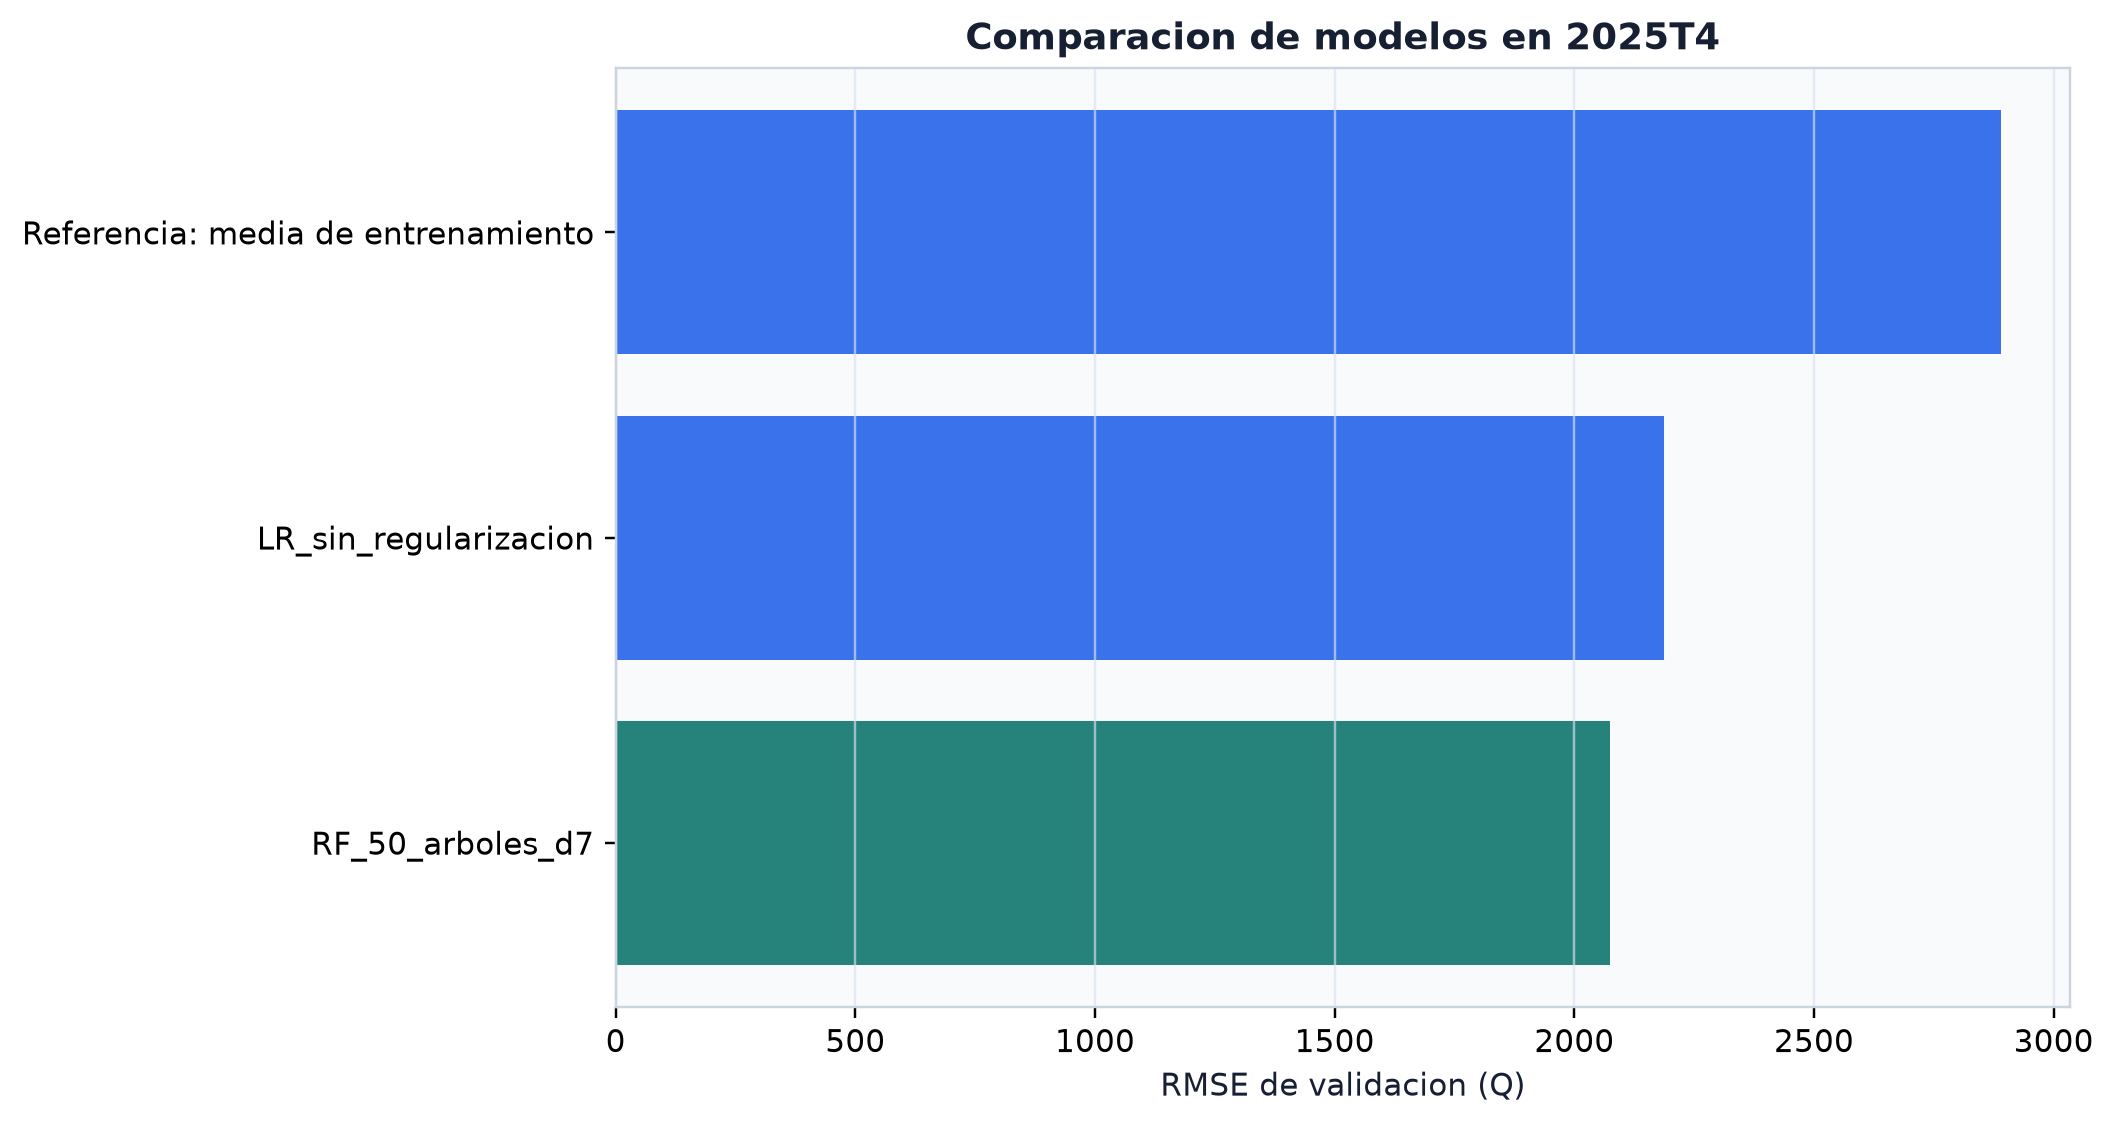

In [ ]:
train = prepared_2025.filter(F.col("periodo_archivo").isin(*TRAIN_PERIODS)).cache()
validation = prepared_2025.filter(F.col("periodo_archivo").isin(*VALIDATION_PERIODS)).cache()
split_counts = pd.DataFrame({
    "conjunto": ["Entrenamiento 2025T1-T3", "Validacion 2025T4", "Test reservado 2026T1"],
    "registros": [train.count(), validation.count(), prepared_2026.count()],
})
display(split_counts)
split_counts.to_csv(TABLES_DIR / "particiones_modelado.csv", index=False)

baseline = baseline_metrics(train, validation)
linear_results, linear_model, best_linear_config = fit_linear_candidates(train, validation)
forest_results, forest_model, best_forest_config = fit_random_forest_candidates(train, validation)
comparison = comparison_table(baseline, linear_results, forest_results)

linear_results.to_csv(TABLES_DIR / "metricas_regresion_lineal.csv", index=False)
forest_results.to_csv(TABLES_DIR / "metricas_random_forest.csv", index=False)
comparison.to_csv(TABLES_DIR / "comparacion_modelos_validacion.csv", index=False)
plot_model_comparison(comparison)

display(HTML("<h4>Regresión lineal: configuraciones</h4>"))
display(linear_results.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Random Forest: configuraciones</h4>"))
display(forest_results.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Comparación con referencia</h4>"))
display(comparison.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(Image(filename=str(FIGURES_DIR / "comparacion_modelos_validacion.png")))

winner = comparison.iloc[0]
baseline_rmse = float(comparison.loc[comparison["modelo"] == "Referencia: media de entrenamiento", "RMSE"].iloc[0])
improvement = 100 * (baseline_rmse - float(winner["RMSE"])) / baseline_rmse
display(HTML(f'''
<div class='lab-note'><b>Resultado de validación.</b> El menor RMSE corresponde a <code>{winner['modelo']}</code>: MAE Q{winner['MAE']:,.2f}, RMSE Q{winner['RMSE']:,.2f} y R² {winner['R2']:.4f}. Frente a la referencia, el RMSE mejora {improvement:.2f}%. Random Forest puede capturar relaciones no lineales e interacciones; la regresión lineal ofrece una estructura más parsimoniosa. La comparación definitiva se hace en la sección 7 con el test 2026.</div>
'''))

## 7. Entrenamiento final y evaluación en 2026

La selección de hiperparámetros ya quedó cerrada con 2025T4 en la sección anterior: se toma la configuración con menor RMSE de validación por algoritmo. Aquí **no se vuelve a escoger nada**; cada pipeline completo (`StringIndexer` → `OneHotEncoder` → `VectorAssembler` → modelo) se ajusta de nuevo con los cuatro trimestres de 2025 y se aplica una sola vez a 2026T1.

- 2026T1 pasó por las mismas reglas de preparación (`harmonize` + `filter_analytical_population`) que 2025; su embudo se guardó en `auditoria_filtros_2026.csv`.
- Ambos modelos se unen por `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA` antes de calcular métricas, de modo que se evalúan sobre exactamente los mismos registros.
- La referencia predice la media salarial de 2025 completo (el mismo conjunto con el que se reentrenan los modelos).
- Las métricas son no ponderadas y se calculan sobre todo el test; el salario objetivo no se recorta ni se transforma.
- Residuo = salario real − salario predicho: positivo indica subestimación y negativo sobreestimación.

In [ ]:
full_train_2025 = prepared_2025.filter(F.col("periodo_archivo").isin(*FINAL_TRAIN_PERIODS)).cache()
test_2026 = prepared_2026.filter(F.col("periodo_archivo").isin(*TEST_PERIODS)).cache()
assert full_train_2025.count() == prepared_2025.count(), "El reentrenamiento debe usar todo 2025"
assert test_2026.count() == prepared_2026.count()

test_key_audit = duplicate_key_audit(harmonized_2026)
assert int(test_key_audit["grupos_duplicados"].iloc[0]) == 0, "Claves duplicadas en 2026"

selected_configs = pd.DataFrame([
    {"algoritmo": "Regresion lineal", **best_linear_config,
     "RMSE_validacion_2025T4": float(linear_results.iloc[0]["RMSE"])},
    {"algoritmo": "Random Forest", **best_forest_config,
     "RMSE_validacion_2025T4": float(forest_results.iloc[0]["RMSE"])},
])
display(HTML("<h4>Configuraciones seleccionadas con 2025T4</h4>"))
display(selected_configs)

final = fit_final_models(full_train_2025, test_2026, best_linear_config, best_forest_config)
test_metrics = final["metrics"]
shared_counts = final["counts"]
final_comparison = final_comparison_table(comparison, test_metrics)

test_metrics.to_csv(TABLES_DIR / "metricas_test_2026.csv", index=False)
final_comparison.to_csv(TABLES_DIR / "comparacion_final_modelos.csv", index=False)
shared_counts.to_csv(TABLES_DIR / "conteo_test_compartido.csv", index=False)
test_key_audit.to_csv(TABLES_DIR / "auditoria_claves_2026.csv", index=False)

display(HTML("<h4>Registros de entrenamiento final y prueba</h4>"))
display(pd.DataFrame({
    "conjunto": ["Entrenamiento final 2025T1-T4", "Prueba 2026T1"],
    "registros": [final["train_rows"], final["test_rows"]],
}))
display(HTML("<h4>Mismo test para ambos modelos</h4>"))
display(shared_counts)
assert shared_counts["registros"].nunique() == 1
display(HTML("<h4>Métricas en 2026T1 (no ponderadas, test completo)</h4>"))
display(test_metrics.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Validación 2025T4 frente a prueba 2026T1</h4>"))
money = [c for c in final_comparison.columns if c.startswith(("MAE", "RMSE", "mejora", "cambio"))]
display(final_comparison.style.format({**{c: "{:,.2f}" for c in money}, "R2": "{:.4f}", "R2_validacion": "{:.4f}"}))

for name in (FINAL_LINEAR_MODEL, FINAL_FOREST_MODEL):
    assert (MODEL_DIR / name / "metadata").exists(), f"No se guardó {name}"
print("Modelos finales:", MODEL_DIR / FINAL_LINEAR_MODEL, "|", MODEL_DIR / FINAL_FOREST_MODEL)
print("Predicciones 2026 (Parquet):", final["predictions_path"])

,algoritmo,nombre,regParam,elasticNetParam,RMSE_validacion_2025T4,numTrees,maxDepth
0,Regresion lineal,LR_sin_regularizacion,0.0,0.0,2186.419579,NaN,NaN
1,Random Forest,RF_50_arboles_d7,NaN,NaN,2074.151763,50.0,7.0


26/09/27 19:50:02 WARN Instrumentation: [cf2f5ef7] regParam is zero, which might cause numerical instability and overfitting.
26/09/27 19:50:02 WARN Instrumentation: [cf2f5ef7] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/27 19:50:04 WARN DAGScheduler: Broadcasting large task binary with size 1123.9 KiB


26/09/27 19:50:06 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


,conjunto,registros
0,Entrenamiento final 2025T1-T4,53025
1,Prueba 2026T1,13258


,conjunto,registros
0,Test elegible 2026T1,13258
1,Predicciones LR_sin_regularizacion,13258
2,Predicciones RF_50_arboles_d7,13258
3,Registros compartidos (join por clave),13258
4,Claves distintas compartidas,13258


,modelo,configuracion,registros,MAE,RMSE,R2
0,Referencia: media 2025,media salarial 2025 completo,13258,"1,718.09","2,871.42",-0.0025
1,LR_sin_regularizacion,"regParam=0.0, elasticNetParam=0.0",13258,"1,240.71","2,163.75",0.4307
2,RF_50_arboles_d7,"numTrees=50, maxDepth=7",13258,"1,141.51","2,050.55",0.4887


,modelo,configuracion,registros,MAE,RMSE,R2,MAE_validacion,RMSE_validacion,R2_validacion,mejora_RMSE_vs_referencia_pct,cambio_RMSE_validacion_a_test
0,RF_50_arboles_d7,"numTrees=50, maxDepth=7",13258,"1,141.51","2,050.55",0.4887,"1,109.94","2,074.15",0.4831,28.59,-23.60
1,LR_sin_regularizacion,"regParam=0.0, elasticNetParam=0.0",13258,"1,240.71","2,163.75",0.4307,"1,210.14","2,186.42",0.4257,24.65,-22.67
2,Referencia: media 2025,media salarial 2025 completo,13258,"1,718.09","2,871.42",-0.0025,"1,672.50","2,889.57",-0.0031,0.00,-18.15


Modelos finales: /opt/app/working_dir/eneic/models/linear_regression_final_2025 | /opt/app/working_dir/eneic/models/random_forest_final_2025
Predicciones 2026 (Parquet): /opt/app/working_dir/eneic/parquet/predicciones_test_2026


In [ ]:
models_only = final_comparison[~final_comparison["modelo"].str.startswith("Referencia")]
test_winner = models_only.iloc[0]
test_runner = models_only.iloc[1]
reference = final_comparison[final_comparison["modelo"].str.startswith("Referencia")].iloc[0]
validation_winner = comparison[~comparison["modelo"].str.startswith("Referencia")].iloc[0]["modelo"]
same_winner = "coincide" if validation_winner == test_winner["modelo"] else "no coincide"

display(HTML(f'''
<div class='lab-note'><b>Interpretación de la prueba 2026.</b>
<ul>
<li><b>Mejor modelo en 2026T1:</b> <code>{test_winner['modelo']}</code> con MAE Q{test_winner['MAE']:,.2f}, RMSE Q{test_winner['RMSE']:,.2f} y R² {test_winner['R2']:.4f}. El otro algoritmo (<code>{test_runner['modelo']}</code>) obtuvo MAE Q{test_runner['MAE']:,.2f}, RMSE Q{test_runner['RMSE']:,.2f} y R² {test_runner['R2']:.4f}.</li>
<li><b>Frente a la referencia:</b> la media de 2025 produce RMSE Q{reference['RMSE']:,.2f} y R² {reference['R2']:.4f}; el ganador reduce el RMSE en {test_winner['mejora_RMSE_vs_referencia_pct']:.2f}%. Que la referencia tenga R² cercano a cero es esperable, porque predice una constante.</li>
<li><b>Estabilidad temporal:</b> el RMSE del ganador cambia Q{test_winner['cambio_RMSE_validacion_a_test']:,.2f} entre validación 2025T4 y prueba 2026T1, y el ganador de validación ({validation_winner}) {same_winner} con el de prueba. Esto indica qué tan bien se sostiene fuera de tiempo la selección hecha solo con 2025.</li>
<li><b>Por qué un algoritmo generaliza mejor:</b> Random Forest captura no linealidades (por ejemplo, rendimientos decrecientes de la edad o la antigüedad) e interacciones entre educación, categoría ocupacional y dominio sin especificarlas; la regresión lineal impone efectos aditivos y constantes. Aun así, ambos dejan sin explicar una parte importante de la variabilidad: faltan variables relevantes (ocupación, rama de actividad, tamaño de empresa) y los salarios extremos pesan mucho en el RMSE.</li>
</ul>
Estas métricas describen los registros elegibles analizados; no son estimaciones oficiales ni implican causalidad.</div>
'''))

## Estado de las actividades

In [ ]:
pending = final_stage_plan()
display(HTML("<div class='lab-pending'><b>Pendiente (actividad 8)</b><ol>" + "".join(f"<li>{item}</li>" for item in pending) + "</ol></div>"))

progress = pd.DataFrame([
    ("1. Carga, armonizacion y calidad", "Completo"),
    ("2. Estadistica descriptiva", "Completo"),
    ("3. Correlaciones", "Completo"),
    ("4. KMeans", "Completo"),
    ("5. Regresion lineal", "Completo"),
    ("6. Random Forest", "Completo"),
    ("7. Evaluacion final 2026", "Completo"),
    ("8. Analisis de errores", "Pendiente"),
], columns=["actividad", "estado"])
display(progress)
progress.to_csv(TABLES_DIR / "estado_avance.csv", index=False)

,actividad,estado
0,"1. Carga, armonizacion y calidad",Completo
1,2. Estadistica descriptiva,Completo
2,3. Correlaciones,Completo
3,4. KMeans,Completo
4,5. Regresion lineal,Completo
5,6. Random Forest,Completo
6,7. Evaluacion final 2026,Completo
7,8. Analisis de errores,Pendiente


## Conclusiones provisionales

El flujo va de los Excel oficiales a Parquet, documenta el efecto de cada filtro, responde la exploración solicitada, compara alternativas de segmentación y selecciona configuraciones supervisadas usando solo 2025T4. La evaluación en 2026T1 se hizo una única vez, con los modelos reentrenados en todo 2025 y sobre exactamente los mismos registros. Las métricas son deliberadamente no ponderadas, por lo que no son estimaciones oficiales. Falta estudiar dónde se concentran los errores, especialmente en salarios altos (actividad 8).

In [ ]:
# Liberación explícita de caché al terminar la ejecución reproducible.
for frame in [raw_2025, raw_2026, harmonized_2025, harmonized_2026, prepared_2025, prepared_2026, train, validation, full_train_2025, test_2026]:
    frame.unpersist()
print("Notebook ejecutado correctamente. Spark queda disponible para inspección interactiva.")

Notebook ejecutado correctamente. Spark queda disponible para inspección interactiva.
